In [1]:
import sys
sys.path.append('../data')
from archi_dict import archi_wheat as archi

from plot_outputs import *

from openalea.archicrop.stics_io import stics_output
from openalea.archicrop.simulation import compute_1_growing_plant
from openalea.archicrop.viability import compute_viable_parameter_space

In [2]:
plant_name = "wheat"

# Wheat

In [3]:
tec_file='../data/usms_STICS/v10/Ble_bis_tec.xml'
plant_file='../data/usms_STICS/v10/plant/wheat_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_swheat.sti'
stics_output_file_pot='../data/usms_STICS/v10/mod_swheat_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)


In [4]:
phi_bounds = [40,160]
rmax_bounds = [0.7,1.0]
N_bounds = [7,20]

d, N, phi, rmax = compute_viable_parameter_space(N_bounds, phi_bounds, rmax_bounds, thermal_time_pot, leaf_area_plant_pot, index_end_veg_pot, archi, end_veg_corr=1)


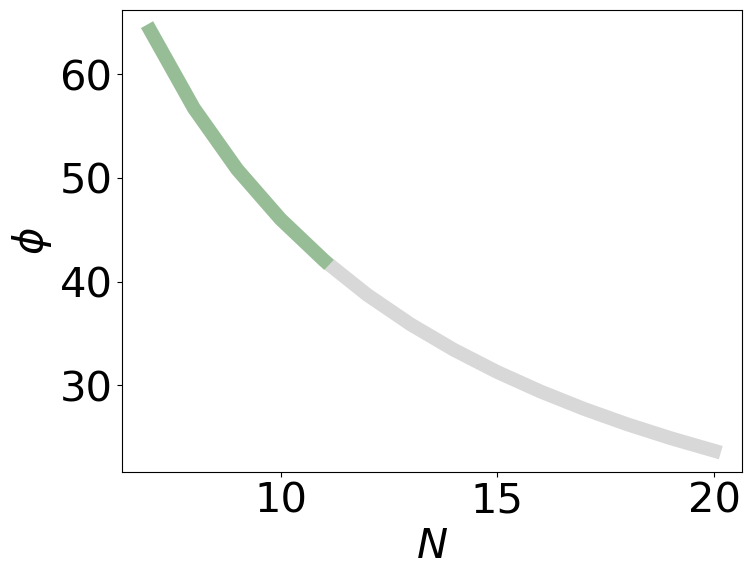

In [5]:
plot_parameter_space_N_phi(plant_name, d, N, phi)

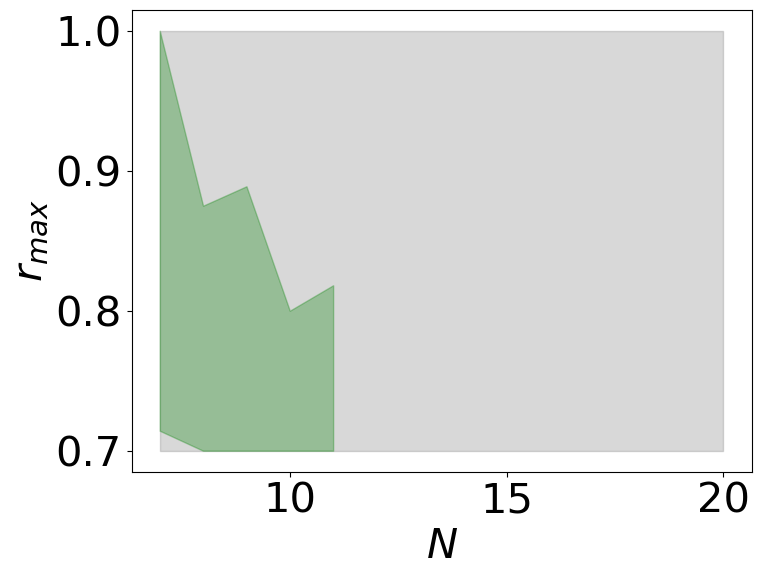

In [6]:
plot_parameter_space_N_rmax(plant_name, d, N, rmax, rmax_bounds)

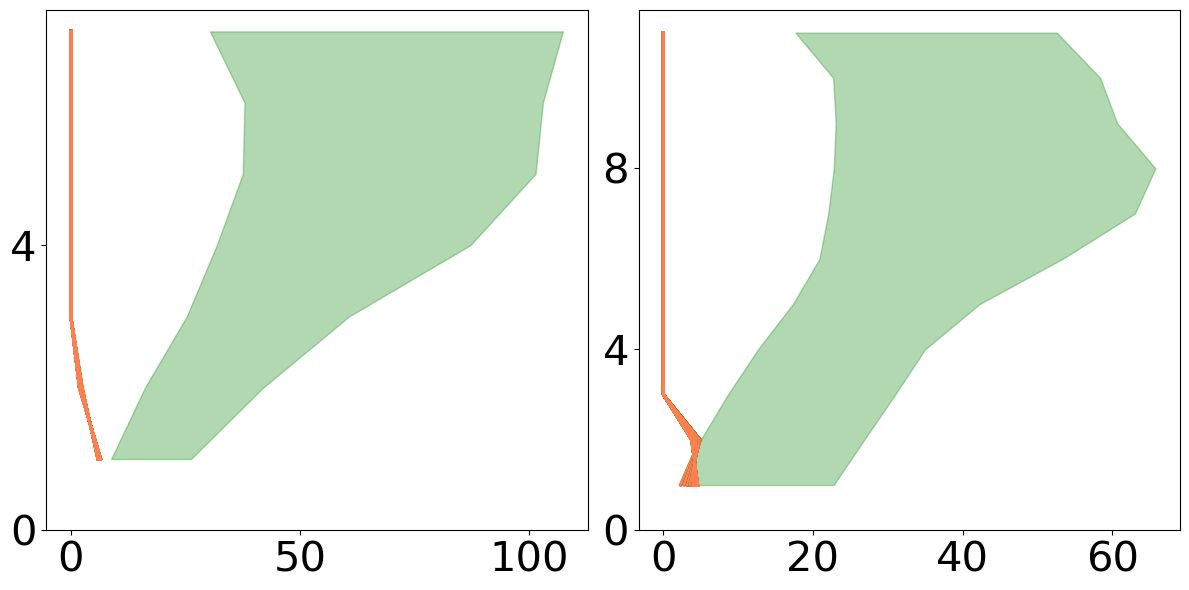

In [7]:
N_viable = [n for n in d if d[n] != []]
N_to_display = [min(N_viable), max(N_viable)]
leaf_profiles(plant_name, N_to_display, archi, stics_output_file, stics_output_file_pot, tec_file, plant_file)

In [11]:
growing_plant = compute_1_growing_plant(archi, d, daily_dynamics, leaf_area_plant_pot, height_canopy_pot, pot_factor=3.5)

Time for 1 simulation of 219 days: 3.4817564487457275


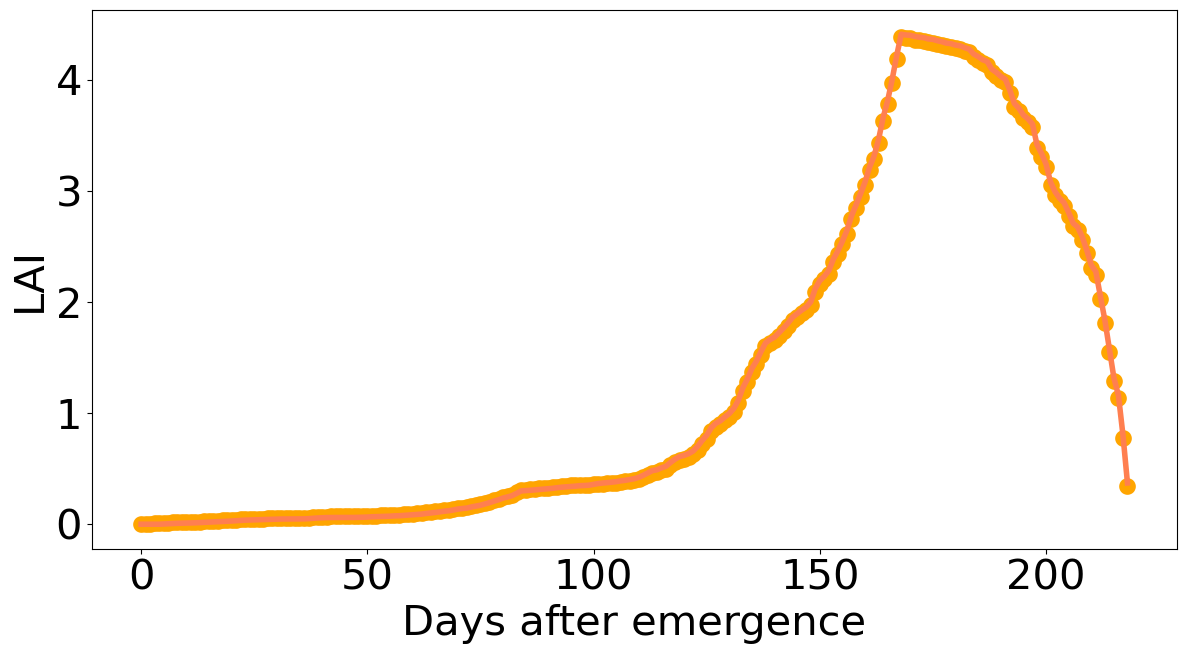

In [12]:
plot_LAI_STICS_and_3D(plant_name, growing_plant, leaf_area_plant, sen_leaf_area_plant, density)

In [14]:
from openalea.archicrop.display import build_scene
from openalea.plantgl.all import Color3, Material, Viewer
from openalea.widgets.plantgl import *
%gui qt
m = Material(Color3(0,80,0))

times = [50,75,100,125,150,175,200,219]
mean_time = sum(times) / len(times)
positions = [(2*(t-mean_time), 0, 0) for t in times]
mtgs_list = [g for i,g in growing_plant.items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)